In [1]:
import pandas as pd
import numpy as np
import re

In [2]:
job_df = pd.read_csv("../Data/job_description_dataset.csv")
resume_df = pd.read_csv("../Data/resume_dataset.csv")

print("Job Dataset:", job_df.shape)
print("Resume Dataset:", resume_df.shape)

Job Dataset: (1068, 7)
Resume Dataset: (10174, 5)


In [15]:
print(job_df["Title"].value_counts().head(30))

Title
.NET Developer                  20
AI Prompt Engineer              20
AR/VR Developer                 20
Big Data Specialist             20
Blockchain Developer            20
Business Analyst                20
Content Writer                  20
Copywriter                      20
Data Engineer                   20
Digital Marketing Specialist    20
Ethical Hacker                  20
Fintech Engineer                20
Game Developer                  20
Graphic Designer                20
JavaScript Developer            20
Java Developer                  20
Marketing Specialist            20
Market Research Analyst         20
Operations Manager              20
Product Designer                20
Product Manager                 20
Project Manager                 20
Python Developer                20
Robotics Engineer               20
Sales Executive                 20
SEO Specialist                  20
Site Reliability Engineer       20
Software Tester (SDET)          20
Solutions Arch

In [16]:
print(resume_df["Role"].value_counts().head(30))

Role
Data Scientist                  538
Software Engineer               480
Product Manager                 458
Data Engineer                   447
UI Engineer                     375
Data Analyst                    329
software engineer               307
data engineer                   307
product manager                 303
data scientist                  287
E-commerce Specialist           268
DevOps Engineer                 266
Machine Learning Engineer       265
Human Resources Specialist      262
Digital Marketing Specialist    260
Robotics Engineer               257
Cloud Architect                 254
QA Engineer                     251
Blockchain Developer            251
Mobile App Developer            247
Full Stack Developer            246
Database Administrator          243
Cloud Engineer                  240
Game Developer                  239
Content Writer                  238
AR/VR Developer                 237
Cybersecurity Analyst           234
UX Designer            

In [21]:
# Get unique job titles from the Job Dataset
job_roles = set(job_df["Title"].str.strip().str.lower())

# Get unique resume roles from the Resume Dataset
resume_roles = set(resume_df["Role"].str.strip().str.lower())

# Find common roles
common_roles = sorted(job_roles.intersection(resume_roles))

print("Number of Common Roles:", len(common_roles))
print("-" * 50)

for role in common_roles:
    job_count = (job_df["Title"].str.lower() == role).sum()
    resume_count = (resume_df["Role"].str.lower() == role).sum()

    print(f"{role.title():35} | Jobs: {job_count:2d} | Resumes: {resume_count:4d}")

Number of Common Roles: 17
--------------------------------------------------
Ar/Vr Developer                     | Jobs: 20 | Resumes:  237
Blockchain Developer                | Jobs: 20 | Resumes:  251
Business Analyst                    | Jobs: 20 | Resumes:  226
Cloud Architect                     | Jobs:  1 | Resumes:  254
Cloud Engineer                      | Jobs:  1 | Resumes:  240
Content Writer                      | Jobs: 20 | Resumes:  238
Cybersecurity Analyst               | Jobs:  2 | Resumes:  234
Data Engineer                       | Jobs: 20 | Resumes:  754
Digital Marketing Specialist        | Jobs: 20 | Resumes:  260
Game Developer                      | Jobs: 20 | Resumes:  239
Graphic Designer                    | Jobs: 20 | Resumes:   15
Network Engineer                    | Jobs:  1 | Resumes:   16
Product Manager                     | Jobs: 20 | Resumes:  761
Project Manager                     | Jobs: 20 | Resumes:   56
Robotics Engineer                   | Jo

In [22]:
selected_role = "data engineer"

job_count = (job_df["Title"].str.lower() == selected_role).sum()
resume_count = (resume_df["Role"].str.lower() == selected_role).sum()

print("=" * 60)
print("SELECTED ROLE FOR EXPERIMENT")
print("=" * 60)

print(f"Selected Role           : {selected_role.title()}")
print(f"Job Descriptions Found  : {job_count}")
print(f"Matching Resumes Found  : {resume_count}")

print("\nReason for Selection:")
print("- Exists in both datasets.")
print("- Sufficient number of job descriptions.")
print("- Large number of matching resumes.")
print("- Technical skills are consistent across candidates.")
print("- Suitable for evaluating SBERT and Skill Matching algorithms.")

SELECTED ROLE FOR EXPERIMENT
Selected Role           : Data Engineer
Job Descriptions Found  : 20
Matching Resumes Found  : 754

Reason for Selection:
- Exists in both datasets.
- Sufficient number of job descriptions.
- Large number of matching resumes.
- Technical skills are consistent across candidates.
- Suitable for evaluating SBERT and Skill Matching algorithms.


In [17]:
# Select Data Engineer job descriptions

data_engineer_jobs = job_df[
    job_df["Title"].str.lower() == "data engineer"
]

print("Number of Data Engineer Jobs:")
print(len(data_engineer_jobs))

sample_job = data_engineer_jobs.iloc[0]

print("\nJob Title:")
print(sample_job["Title"])

print("\nRequired Skills:")
print(sample_job["Skills"])

Number of Data Engineer Jobs:
20

Job Title:
Data Engineer

Required Skills:
Python; Java Basics; SQL; PostgreSQL; MongoDB; Hadoop Basics; Spark Basics; ETL Fundamentals; AWS Basics; Azure Fundamentals


In [18]:
data_engineer_resumes = resume_df[
    resume_df["Role"].str.lower() == "data engineer"
]

print("Number of Data Engineer Resumes:")
print(len(data_engineer_resumes))

Number of Data Engineer Resumes:
754


In [20]:
sample_resumes = data_engineer_resumes.head(10)

print(sample_resumes[["Role"]])

              Role
22   Data Engineer
49   Data Engineer
54   Data Engineer
141  Data Engineer
142  Data Engineer
155  Data Engineer
173  Data Engineer
179  Data Engineer
195  Data Engineer
196  Data Engineer


In [23]:
print("=" * 60)
print("SELECTED JOB DESCRIPTION")
print("=" * 60)

print("Job Title:")
print(sample_job["Title"])

print("\nExperience Level:")
print(sample_job["ExperienceLevel"])

print("\nYears of Experience:")
print(sample_job["YearsOfExperience"])

print("\nRequired Skills:")
print(sample_job["Skills"])

SELECTED JOB DESCRIPTION
Job Title:
Data Engineer

Experience Level:
Fresher

Years of Experience:
0-1

Required Skills:
Python; Java Basics; SQL; PostgreSQL; MongoDB; Hadoop Basics; Spark Basics; ETL Fundamentals; AWS Basics; Azure Fundamentals


In [32]:
# Clean and normalize required skills

required_skills = []

for skill in sample_job["Skills"].split(";"):

    skill = skill.strip().lower()

    # Remove unnecessary words
    skill = skill.replace(" basics", "")
    skill = skill.replace(" fundamentals", "")

    required_skills.append(skill)

print("Normalized Required Skills")
print("-" * 40)

for skill in required_skills:
    print(skill)

Normalized Required Skills
----------------------------------------
python
java
sql
postgresql
mongodb
hadoop
spark
etl
aws
azure


In [33]:
print("=" * 60)
print("FIRST DATA ENGINEER RESUME")
print("=" * 60)

print(sample_resumes.iloc[0]["Resume"][:1200])

FIRST DATA ENGINEER RESUME
Here's a professional resume for Mrs. Brittany George:

Brittany George
Contact Information:

* Email: [brittany.george@email.com](mailto:brittany.george@email.com)
* Phone: 555-555-5555
* LinkedIn: linkedin.com/in/brittanygeorge
* GitHub: github.com/brittanygeorge

Professional Summary:
Highly motivated and detail-oriented Data Engineer with 5+ years of experience in designing, developing, and deploying data pipelines using MLOps, Airflow, ETL, and Big Data technologies. Proven track record of successfully implementing scalable and efficient data architectures on cloud platforms, including Spark and cloud-based data warehousing solutions. Skilled in leading cross-functional teams to deliver high-quality data products and driving business growth through data-driven insights.

Technical Skills:

* MLOps: Model deployment, model monitoring, and A/B testing
* Airflow: Workflow management, DAG design, and scheduling
* ETL: Data extraction, transformation, and loa

In [34]:
# Create an empty list to store the results
results = []

# Loop through each selected resume
for index, row in sample_resumes.iterrows():

    resume_text = row["Resume"].lower()

    matched_skills = []
    missing_skills = []

    # Compare required skills with resume
    for skill in required_skills:

        if skill in resume_text:
            matched_skills.append(skill)
        else:
            missing_skills.append(skill)

    # Calculate Skill Match Percentage
    skill_match = (len(matched_skills) / len(required_skills)) * 100

    # Save the results
    results.append({
        "Resume_ID": index,
        "Matched_Skills": ", ".join(matched_skills),
        "Missing_Skills": ", ".join(missing_skills),
        "Matched_Count": len(matched_skills),
        "Skill_Match_Percentage": round(skill_match, 2)
    })

In [35]:
skill_match_df = pd.DataFrame(results)

skill_match_df = skill_match_df.sort_values(
    by="Skill_Match_Percentage",
    ascending=False
)

skill_match_df.reset_index(drop=True, inplace=True)

skill_match_df.index = skill_match_df.index + 1
skill_match_df.index.name = "Rank"

skill_match_df

,Resume_ID,Matched_Skills,Missing_Skills,Matched_Count,Skill_Match_Percentage
Rank,,,,,
1,22,"python, sql, hadoop, spark, etl, aws, azure","java, postgresql, mongodb",7,70.0
2,49,"python, java, sql, hadoop, spark, aws, azure","postgresql, mongodb, etl",7,70.0
3,141,"python, java, hadoop, spark, etl, aws, azure","sql, postgresql, mongodb",7,70.0
4,196,"python, java, hadoop, spark, etl, aws, azure","sql, postgresql, mongodb",7,70.0
5,195,"python, java, hadoop, spark, etl, aws, azure","sql, postgresql, mongodb",7,70.0
6,54,"python, java, hadoop, spark, aws, azure","sql, postgresql, mongodb, etl",6,60.0
7,155,"python, java, hadoop, spark, aws, azure","sql, postgresql, mongodb, etl",6,60.0
8,142,"python, java, sql, hadoop, spark, etl","postgresql, mongodb, aws, azure",6,60.0
9,173,"python, java, sql, hadoop, spark, etl","postgresql, mongodb, aws, azure",6,60.0


In [36]:
skill_match_df[
    [
        "Resume_ID",
        "Matched_Count",
        "Skill_Match_Percentage"
    ]
]

,Resume_ID,Matched_Count,Skill_Match_Percentage
Rank,,,
1,22,7,70.0
2,49,7,70.0
3,141,7,70.0
4,196,7,70.0
5,195,7,70.0
6,54,6,60.0
7,155,6,60.0
8,142,6,60.0
9,173,6,60.0


In [37]:
# Display detailed matching information

for i in range(len(skill_match_df)):

    print("=" * 70)
    print(f"Rank #{i+1}")
    print("=" * 70)

    print("Resume ID:")
    print(skill_match_df.iloc[i]["Resume_ID"])

    print("\nMatched Skills:")
    print(skill_match_df.iloc[i]["Matched_Skills"])

    print("\nMissing Skills:")
    print(skill_match_df.iloc[i]["Missing_Skills"])

    print("\nSkill Match Percentage:")
    print(f'{skill_match_df.iloc[i]["Skill_Match_Percentage"]}%')

    print("\n")

Rank #1
Resume ID:
22

Matched Skills:
python, sql, hadoop, spark, etl, aws, azure

Missing Skills:
java, postgresql, mongodb

Skill Match Percentage:
70.0%


Rank #2
Resume ID:
49

Matched Skills:
python, java, sql, hadoop, spark, aws, azure

Missing Skills:
postgresql, mongodb, etl

Skill Match Percentage:
70.0%


Rank #3
Resume ID:
141

Matched Skills:
python, java, hadoop, spark, etl, aws, azure

Missing Skills:
sql, postgresql, mongodb

Skill Match Percentage:
70.0%


Rank #4
Resume ID:
196

Matched Skills:
python, java, hadoop, spark, etl, aws, azure

Missing Skills:
sql, postgresql, mongodb

Skill Match Percentage:
70.0%


Rank #5
Resume ID:
195

Matched Skills:
python, java, hadoop, spark, etl, aws, azure

Missing Skills:
sql, postgresql, mongodb

Skill Match Percentage:
70.0%


Rank #6
Resume ID:
54

Matched Skills:
python, java, hadoop, spark, aws, azure

Missing Skills:
sql, postgresql, mongodb, etl

Skill Match Percentage:
60.0%


Rank #7
Resume ID:
155

Matched Skills:
pyt

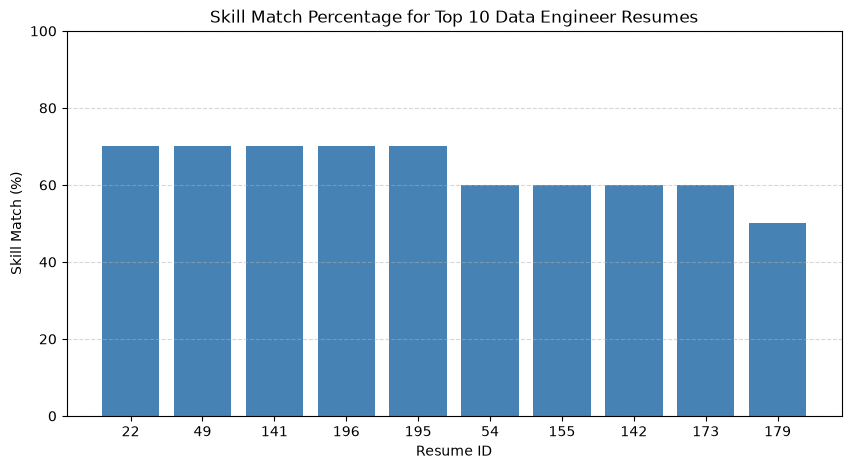

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    skill_match_df["Resume_ID"].astype(str),
    skill_match_df["Skill_Match_Percentage"],
    color="steelblue"
)

plt.title("Skill Match Percentage for Top 10 Data Engineer Resumes")
plt.xlabel("Resume ID")
plt.ylabel("Skill Match (%)")

plt.ylim(0,100)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()